In [1]:
# Core imports
import numpy as np
import torch
import sys
from pathlib import Path
# Add project root to Python path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Import modules
from src.data.dataset import create_data_loaders
from src.models.deeplog import DeepLogModel
from src.engine.trainer import LogSeqTrainer
from src.utils.metrics import evaluate_model, print_metrics, save_experiment_results
from src.utils.data_loader import create_train_val_test_split, filter_normal_samples, load_loghub
from src.utils.visualizer import UniversalAnomalyVisualizer
from src.utils.seed import seed_everything

In [2]:
seed_everything(42)  # For reproducibility

In [3]:
# Define paths
DATA_DIR = '../../data/bgl/preprocessed'

In [4]:
X, y, vocab = load_loghub(DATA_DIR)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")
print(f"Events: {sorted(vocab.keys())[:10]}")  # See first 10

INFO:src.utils.data_loader:Loading data from LogHub preprocessing: ../../data/bgl/preprocessed
INFO:src.utils.data_loader:Loaded data:
INFO:src.utils.data_loader:  - Sequences: (949589, 20)
INFO:src.utils.data_loader:  - Labels: (949589,)
INFO:src.utils.data_loader:  - Normal: 868556, Anomaly: 81033
INFO:src.utils.data_loader:  - Loaded vocabulary: 371 events


Vocab size: 371
Events: ['<PAD>', '<UNK>', 'E1', 'E10', 'E100', 'E101', 'E102', 'E103', 'E1035', 'E1036']


In [5]:
#  Split data (70/15/15)
splits = create_train_val_test_split(X, y, train_ratio=0.7, val_ratio=0.15, random_state=42)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = splits['train'], splits['val'], splits['test']
X_train, y_train = filter_normal_samples(X_train, y_train, verbose=True)

INFO:src.utils.data_loader:Splitting data: train=0.7, val=0.15, test=0.15
INFO:src.utils.data_loader:Split complete:
INFO:src.utils.data_loader:  - Train: 664711 samples (56723 anomalies)
INFO:src.utils.data_loader:  - Val:   142439 samples (12155 anomalies)
INFO:src.utils.data_loader:  - Test:  142439 samples (12155 anomalies)
INFO:src.utils.data_loader:======================================================================
INFO:src.utils.data_loader:FILTERING TRAINING DATA FOR SEMI-SUPERVISED LEARNING
INFO:src.utils.data_loader:======================================================================
INFO:src.utils.data_loader:Original training size: 664711 samples
INFO:src.utils.data_loader:  Normal samples: 607,988 (91.47%)
INFO:src.utils.data_loader:  Anomaly samples: 56,723 (8.53%)
INFO:src.utils.data_loader:
Filtered training size: 607,988 samples (NORMAL ONLY)
INFO:src.utils.data_loader:Removed 56,723 anomalies from training set
INFO:src.utils.data_loader:✓ Training data is now pur

In [6]:
print(f"Unique events in first 100 train sequences: {len(set(e for seq in X_train[:100] for e in seq))}")
print(f"Max event ID: {max(e for seq in X_train for e in seq)}")
print(f"Min event ID: {min(e for seq in X_train for e in seq)}")
print(f"Train shape: {X_train.shape}")

Unique events in first 100 train sequences: 40
Max event ID: 370
Min event ID: 1
Train shape: (607988, 20)


In [7]:
# Get optimal dataloader kwargs
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
loader_kwargs = LogSeqTrainer.get_optimal_dataloader_kwargs(device)
loader_kwargs

{'pin_memory': False, 'num_workers': 4}

In [8]:
batch_size = 64
train_loader, val_loader, test_loader = create_data_loaders(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    batch_size=batch_size,
    **loader_kwargs
)

In [9]:
#  Create model
model = DeepLogModel(
    vocab_size=vocab_size,
    embedding_dim=64,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3 
)
print(model)

DeepLogModel(
  (embedding): Embedding(371, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout_layer): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=371, bias=True)
)


In [ ]:
# Train
print(f"Training on {device} device.")
learning_rate = 0.001
trainer = LogSeqTrainer(model, device=device, learning_rate=learning_rate)
patience = 10
history = trainer.fit(
    train_loader, val_loader,
    num_epochs=50,
    early_stopping_patience=patience,
    print_every=5
)

Training on mps device.


Training: 100%|██████████| 9500/9500 [00:43<00:00, 217.63it/s]



Epoch 1/50 - 55.44s
  Train Loss: 0.2197
  Val Loss:   0.8456
  ✓ New best model (val_loss: 0.8456)


Training: 100%|██████████| 9500/9500 [00:42<00:00, 224.34it/s]



Epoch 5/50 - 53.27s
  Train Loss: 0.1659
  Val Loss:   0.7244
  ✓ New best model (val_loss: 0.7244)


...


Epoch 10/50 - 53.37s
  Train Loss: 0.1642
  Val Loss:   0.7222
  No improvement (4/10)


Training: 100%|██████████| 9500/9500 [00:42<00:00, 225.12it/s]



Epoch 15/50 - 53.72s
  Train Loss: 0.1637
  Val Loss:   0.7099
  No improvement (9/10)


Training: 100%|██████████| 9500/9500 [00:42<00:00, 225.91it/s]



Early stopping triggered after 16 epochs

✓ Loaded best model (val_loss: 0.7068)
Total training time: 856.23s


In [24]:
# Evaluate
# Capture predictions, true labels, AND anomaly scores from the loader
top_k = 11
predictions, true_labels, anomaly_scores = trainer.detect_anomalies(test_loader, top_k=top_k, return_scores=True)
metrics = evaluate_model(predictions, true_labels) 
print_metrics(metrics)

Detecting anomalies: 100%|██████████| 2226/2226 [00:15<00:00, 145.63it/s]


EVALUATION METRICS
Accuracy:  0.9880 (98.80%)
Precision: 0.8824
Recall:    0.9914
F1-Score:  0.9337

Confusion Matrix:
              Predicted
              Normal  Anomaly
Actual Normal   128678     1606
       Anomaly     105    12050


✓ Saved: ../../figures/deeplog/training_history.png


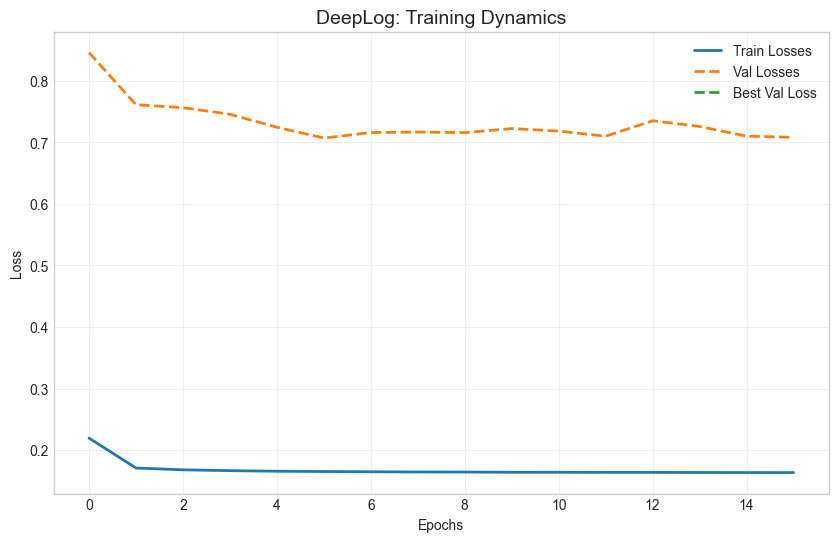

✓ Saved: ../../figures/deeplog/confusion_matrix.png


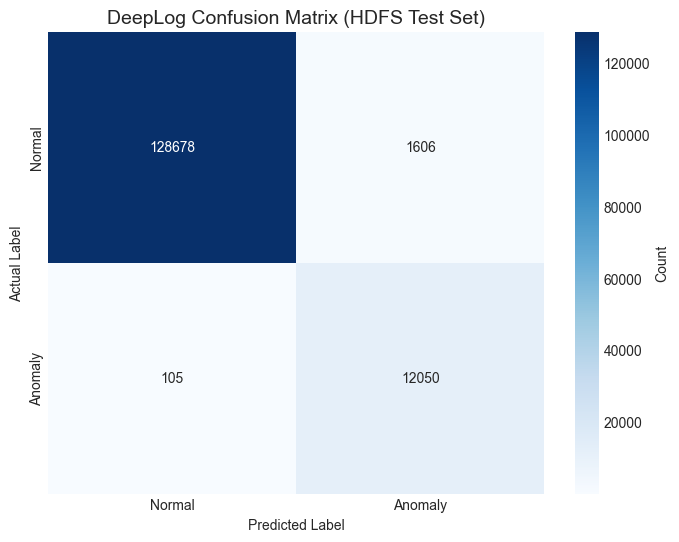

✓ Saved: ../../figures/deeplog/anomaly_score_distribution.png


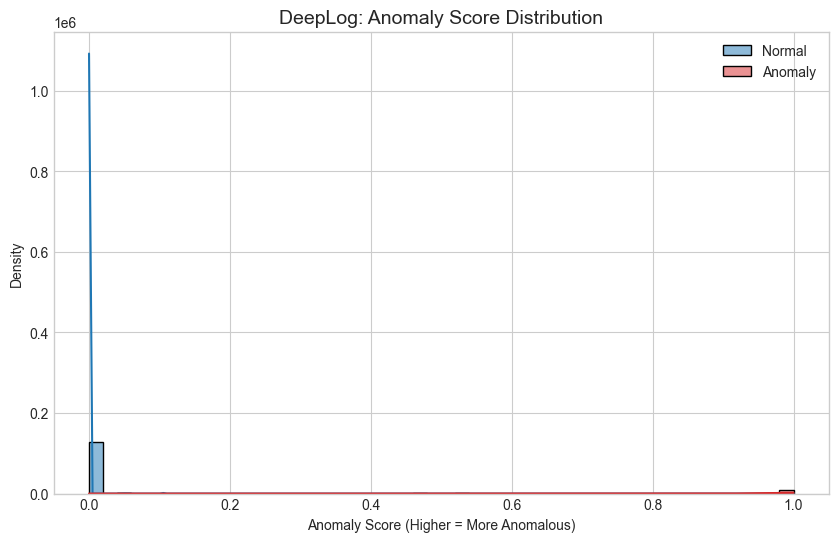

✓ Saved: ../../figures/deeplog/roc_curve.png


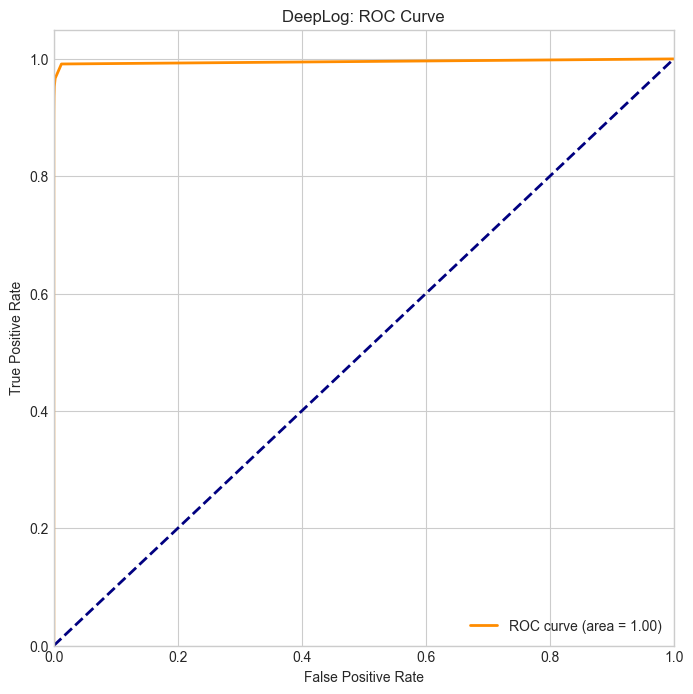

✓ Saved: ../../figures/deeplog/precision_recall_curve.png


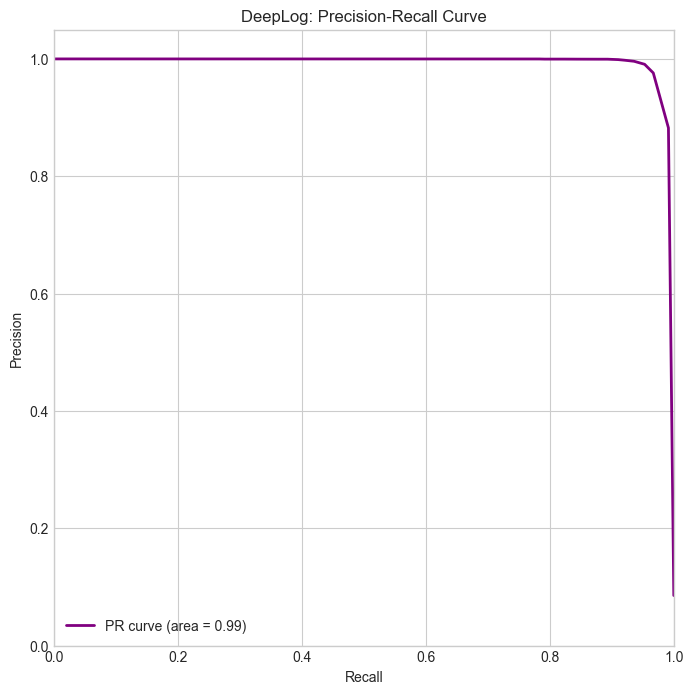


✓ All visualizations generated and saved using UniversalAnomalyVisualizer


In [25]:
### 6. Visualizations
viz = UniversalAnomalyVisualizer(model_name="DeepLog", save_dir="../../figures/deeplog")

# Plot 1: Training History (Loss curves)
viz.plot_training_history(history)

# Plot 2: Confusion Matrix
viz.plot_confusion_matrix(true_labels, predictions, title_suffix="(HDFS Test Set)")

# Plot 3: Anomaly Score Distribution
viz.plot_anomaly_score_distribution(true_labels, anomaly_scores, bins=50)

# Plot 4: ROC Curve
viz.plot_roc_curve(true_labels, anomaly_scores)

# Plot 5: Precision-Recall Curve
viz.plot_precision_recall_curve(true_labels, anomaly_scores)

print("\n✓ All visualizations generated and saved using UniversalAnomalyVisualizer")

In [26]:
#  Save results
save_experiment_results(
    filepath="../../results/bgl_deeplog_results.json",
    dataset="BGL",
    model_name="DeepLog",
    device=device,
    model=model,
    history=history,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    metrics=metrics,
    batch_size=batch_size,
    learning_rate=learning_rate,
    patience=patience,
    top_k=top_k
)

✓ Results saved to ../../results/bgl_deeplog_results.json


{'dataset': 'BGL',
 'model': 'DeepLog',
 'device': 'mps',
 'architecture': {'vocab_size': 371,
  'embedding_dim': 64,
  'hidden_dim': 128,
  'num_layers': 2,
  'dropout': 0.3},
 'training': {'num_epochs': 16,
  'batch_size': 64,
  'learning_rate': 0.001,
  'early_stopping_patience': 10,
  'best_val_loss': 0.7068191990356721,
  'training_time_seconds': 856.2268240451813},
 'data': {'train_size': 607988,
  'val_size': 142439,
  'test_size': 142439,
  'max_sequence_length': None,
  'train_normal_only': True},
 'detection': {'top_k': 11, 'method': 'next_event_prediction'},
 'metrics': {'accuracy': 0.9879878404088768,
  'precision': 0.8823960164030463,
  'recall': 0.9913615795968738,
  'f1': 0.9337104335360893,
  'confusion_matrix': [[128678, 1606], [105, 12050]]}}